# Embedding Analysis — Cosine Similarity Divergence
For a given ticker, find its top-N most financially similar companies
that diverge most in embedding space, and plot cosine similarity over time.

In [39]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from IPython.display import display

pd.set_option('display.float_format', '{:.4f}'.format)

ROOT           = Path('../')
PREPROCESS_DIR = ROOT / 'data' / 'out' / 'preprocess'
META_DIR       = ROOT / 'data' / 'in'
MODEL_PATH     = ROOT / 'mlartifacts/969401890363820521/e7e0b7a295fc4a149ac0c24b0220074a/artifacts/tin20-tout4-latent80_ctx.pth'

T_IN              = 20
T_OUT             = 4
NORM_MODE         = 'global'
MACRO_WEIGHT_MODE = 'xgboost'
DEVICE            = torch.device('cpu')

## 1. Load & pre-process data

In [40]:
from services.data import load_raw_data, filter_columns, ColumnFilter
from services.transforms import symmetric_log

bs_df, is_df, cf_df, macro_df, metadata_df = load_raw_data(
    PREPROCESS_DIR, META_DIR, norm_mode=NORM_MODE
)
bs_f, is_f, cf_f, macro_f = filter_columns(
    bs_df, is_df, cf_df, macro_df, cond=ColumnFilter.DIFF_Y
)

print(f"BS cols: {len([c for c in bs_f.columns if 'DIFF' in c])}")
print(f"IS cols: {len([c for c in is_f.columns if 'DIFF' in c])}")
print(f"CF cols: {len([c for c in cf_f.columns if 'DIFF' in c])}")
print(f"Macro cols: {len([c for c in macro_f.columns if c != 'quarter'])}")

BS cols: 23
IS cols: 12
CF cols: 5
Macro cols: 7


## 2. Build sliding windows per company

In [41]:
def build_window_dataset(bs_f, is_f, cf_f, macro_f, T_in):
    """Merge all statements and create T_in-step sliding windows per company.
    
    Returns raw (un-transformed) tensors plus a meta_df with (ticker, end_quarter)
    for each window row.
    """
    df = (
        bs_f.merge(is_f, on=["ticker", "quarter"])
            .merge(cf_f, on=["ticker", "quarter"])
            .merge(macro_f, on="quarter")
            .sort_values(["ticker", "quarter"])
    )

    macro_cols = [c for c in macro_f.columns if c != "quarter"]
    fin_cols   = [c for c in df.columns if c not in ["ticker", "quarter"] + macro_cols]

    X_fin_list, X_mac_list, meta = [], [], []

    for ticker, g in df.groupby("ticker"):
        if len(g) < T_in:
            continue
        f = g[fin_cols].values.astype(np.float32)
        m = g[macro_cols].values.astype(np.float32)
        q = g["quarter"].values

        for i in range(len(g) - T_in + 1):
            X_fin_list.append(f[i : i + T_in])
            X_mac_list.append(m[i : i + T_in])
            meta.append({"ticker": ticker, "end_quarter": q[i + T_in - 1]})

    return (
        torch.tensor(np.stack(X_fin_list)),
        torch.tensor(np.stack(X_mac_list)),
        pd.DataFrame(meta),
        fin_cols,
        macro_cols,
    )


X_fin_raw, X_mac_raw, meta_df, fin_cols, macro_cols = build_window_dataset(
    bs_f, is_f, cf_f, macro_f, T_IN
)

print(f"Total windows : {len(meta_df)}")
print(f"Companies     : {meta_df['ticker'].nunique()}")
print(f"Fin features  : {X_fin_raw.shape[-1]}")
print(f"Macro features: {X_mac_raw.shape[-1]}")

Total windows : 65627
Companies     : 2263
Fin features  : 40
Macro features: 7


## 3. Apply transforms  
Symmetric log + per-company XGBoost macro weighting (one weight vector per company,
fitted on its full available history, then broadcast to every window).

In [42]:
from xgboost import XGBRegressor


def _sym_log_np(x: np.ndarray) -> np.ndarray:
    return np.sign(x) * np.log1p(np.abs(x))


def compute_company_macro_weights(
    bs_f, is_f, cf_f, macro_f, fin_cols, macro_cols
):
    """Return dict {ticker: weight_vector [M]} using XGBoost importance
    fitted on each company's full available history.
    """
    df = (
        bs_f.merge(is_f, on=["ticker", "quarter"])
            .merge(cf_f, on=["ticker", "quarter"])
            .merge(macro_f, on="quarter")
            .sort_values(["ticker", "quarter"])
    )

    weights = {}
    for ticker, g in df.groupby("ticker"):
        f   = _sym_log_np(g[fin_cols].values.astype(np.float64))
        m   = _sym_log_np(g[macro_cols].values.astype(np.float64))
        sig = f.mean(axis=1)          # aggregate financial signal [T]

        if np.std(sig) < 1e-8 or len(sig) < 5:
            weights[ticker] = np.ones(len(macro_cols), dtype=np.float32)
            continue

        imp = XGBRegressor(
            n_estimators=50, max_depth=3, verbosity=0, random_state=42
        ).fit(m, sig).feature_importances_

        # sign-correct: positive correlation → keep sign, negative → flip
        sig_c = sig - sig.mean()
        signs = np.sign(
            np.array([
                (sig_c * (m[:, j] - m[:, j].mean())).mean()
                for j in range(m.shape[1])
            ])
        )
        signs[signs == 0] = 1
        weights[ticker] = (imp * signs).astype(np.float32)

    return weights


print("Computing per-company macro weights...")
company_weights = compute_company_macro_weights(
    bs_f, is_f, cf_f, macro_f, fin_cols, macro_cols
)
print(f"Done — {len(company_weights)} companies.")

Computing per-company macro weights...
Done — 2263 companies.


In [43]:
# Apply symmetric log then broadcast company weights to every window
X_fin_t = symmetric_log(X_fin_raw)
X_mac_t = symmetric_log(X_mac_raw).clone()

tickers_arr = meta_df["ticker"].values
for idx, ticker in enumerate(tickers_arr):
    w = torch.tensor(company_weights[ticker])   # [M]
    X_mac_t[idx] = X_mac_t[idx] * w.unsqueeze(0)  # [T_in, M]

print(f"X_fin_t : {X_fin_t.shape}")
print(f"X_mac_t : {X_mac_t.shape}")

X_fin_t : torch.Size([65627, 20, 40])
X_mac_t : torch.Size([65627, 20, 7])


## 4. Load model and generate embeddings

In [44]:
from models.autoencoder_dlinear_forecaster import ForecastingAE

F_DIM      = X_fin_t.shape[-1]   # 40
M_DIM      = X_mac_t.shape[-1]   # 7
LATENT_DIM = 80

model = ForecastingAE(T_IN, T_OUT, F_DIM, M_DIM, LATENT_DIM).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"Model loaded  — latent dim: {LATENT_DIM}, F: {F_DIM}, M: {M_DIM}")

Model loaded  — latent dim: 80, F: 40, M: 7


In [45]:
BATCH = 512
Z_list = []

with torch.no_grad():
    for start in range(0, len(X_fin_t), BATCH):
        xf = X_fin_t[start : start + BATCH].to(DEVICE)
        xm = X_mac_t[start : start + BATCH].to(DEVICE)
        z, _ = model(xf, xm)
        Z_list.append(z.cpu())

Z = torch.cat(Z_list)   # [N_total, LATENT_DIM]
print(f"Embeddings shape: {Z.shape}")

Embeddings shape: torch.Size([65627, 80])


## 5. Per-company aggregation
Average embeddings and financial representations over all sliding windows for each company.

In [46]:
# Financial rep per window: mean-pool over the time axis → [N_total, F]
fin_reps_all = X_fin_t.mean(dim=1).numpy()
emb_reps_all = Z.numpy()

company_list = sorted(meta_df["ticker"].unique())

fin_per_company = np.stack([
    fin_reps_all[tickers_arr == t].mean(axis=0)
    for t in company_list
])   # [N_companies, F]

emb_per_company = np.stack([
    emb_reps_all[tickers_arr == t].mean(axis=0)
    for t in company_list
])   # [N_companies, LATENT_DIM]

print(f"Companies in analysis : {len(company_list)}")
print(f"Financial matrix      : {fin_per_company.shape}")
print(f"Embedding matrix      : {emb_per_company.shape}")

Companies in analysis : 2263
Financial matrix      : (2263, 40)
Embedding matrix      : (2263, 80)


## 6. Pairwise cosine similarity matrices

In [47]:
cos_fin = cos_sim(fin_per_company)   # [N_companies, N_companies]
cos_emb = cos_sim(emb_per_company)   # [N_companies, N_companies]
delta   = cos_fin - cos_emb          # positive → more similar in raw finance than in embedding

cos_fin_df  = pd.DataFrame(cos_fin,  index=company_list, columns=company_list)
cos_emb_df  = pd.DataFrame(cos_emb,  index=company_list, columns=company_list)
delta_df    = pd.DataFrame(delta,    index=company_list, columns=company_list)

print("Delta statistics (off-diagonal):")
off_diag = delta[~np.eye(len(company_list), dtype=bool)]
print(pd.Series(off_diag).describe())

Delta statistics (off-diagonal):
count   5118906.0000
mean         -0.3401
std           0.4333
min          -1.7332
25%          -0.6383
50%          -0.1147
75%          -0.0033
max           0.7586
dtype: float64


## 7. Top-3 divergent peers for a given ticker

In [110]:
# Precompute (ticker, end_quarter) → row index for fast per-quarter lookups
tq_to_idx = {
    (row.ticker, row.end_quarter): i
    for i, row in meta_df.reset_index(drop=True).iterrows()
}


def get_divergent_pairs(ticker: str, n: int = 3) -> pd.DataFrame:
    """Return the n peers with the highest  cos_fin * |delta|  score.

    Prioritises pairs that are genuinely similar in financial space
    (high cos_fin) *and* most disagreed upon by the embedding (large |delta|).

    Parameters
    ----------
    ticker : company whose row in the similarity matrix is examined.
    n      : number of most-divergent peers to return.

    Returns
    -------
    DataFrame with columns [peer, cos_fin, cos_emb, delta].
    """
    if ticker not in company_list:
        raise ValueError(f"{ticker!r} not found. Available: {company_list[:5]}...")

    idx          = company_list.index(ticker)
    row_delta    = delta[idx].copy()
    row_cos_fin  = cos_fin[idx].copy()
    row_delta[idx]   = 0.0
    row_cos_fin[idx] = 0.0   # exclude self

    # score = financial similarity * |divergence|:
    # rewards pairs that are genuinely similar in financial space
    # but most disagreed upon by the embedding
    score = np.clip(row_cos_fin, 0, None) * np.abs(row_delta)
    top_idx = np.argsort(score)[::-1][:n]

    return pd.DataFrame([
        {
            "peer"    : company_list[i],
            "cos_fin" : float(row_cos_fin[i]),
            "cos_emb" : float(cos_emb[idx, i]),
            "delta"   : float(row_delta[i]),
            "score"   : float(score[i]),
        }
        for i in top_idx
    ])


def _pair_timeseries(ticker: str, peer: str):
    """Compute per-quarter cosine similarity between ticker and peer.

    Returns (quarters, fin_sims, emb_sims) aligned on common end_quarters.
    """
    ticker_qs = set(meta_df.loc[tickers_arr == ticker, "end_quarter"])
    peer_qs   = set(meta_df.loc[tickers_arr == peer,   "end_quarter"])
    common_qs = sorted(ticker_qs & peer_qs)

    fin_sims, emb_sims = [], []
    for q in common_qs:
        ti = tq_to_idx[(ticker, q)]
        pi = tq_to_idx[(peer,   q)]
        fin_sims.append(
            float(cos_sim(fin_reps_all[[ti]], fin_reps_all[[pi]])[0, 0])
        )
        emb_sims.append(
            float(cos_sim(emb_reps_all[[ti]], emb_reps_all[[pi]])[0, 0])
        )

    return common_qs, fin_sims, emb_sims


def plot_divergent_pairs(
    ticker: str,
    n: int = 3,
    figsize: tuple | None = None,
) -> pd.DataFrame:
    """For each of the n most divergent peers, plot cosine similarity over time.

    Each subplot shows two lines — financial cosine and embedding cosine — for
    the (ticker, peer) pair across all quarters they share.  The shaded area
    highlights the gap (delta = financial − embedding).

    Returns the summary DataFrame from get_divergent_pairs.
    """
    pairs = get_divergent_pairs(ticker, n)

    if figsize is None:
        figsize = (7, 3.5 * n)

    fig, axes = plt.subplots(n, 1, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    fig.suptitle(
        f"{ticker}: Top-{n} most divergent peers\n",
        fontsize=13,
    )

    for ax, (_, row) in zip(axes, pairs.iterrows()):
        peer = row["peer"]
        quarters, fin_sims, emb_sims = _pair_timeseries(ticker, peer)

        if not quarters:
            ax.set_title(f"{peer}  (no common quarters)")
            continue

        xs = range(len(quarters))

        line_fin, = ax.plot(xs, fin_sims, color="#4C72B0", linewidth=1.8,
                            marker="o", markersize=3, label="Financial")
        line_emb, = ax.plot(xs, emb_sims, color="#DD8452", linewidth=1.8,
                            marker="o", markersize=3, label="Embedding")
        patch_gap = ax.fill_between(xs, fin_sims, emb_sims,
                                    alpha=0.15, color="gray", label="Gap")
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

        # x-ticks: show ~10 labels to avoid crowding
        step  = max(1, len(quarters) // 10)
        ticks = list(range(0, len(quarters), step))
        ax.set_xticks(ticks)
        ax.set_xticklabels([quarters[i] for i in ticks], rotation=30, ha="right", fontsize=8)

        agg_delta = row["delta"]
        sign_str  = f"+{agg_delta:.3f}" if agg_delta >= 0 else f"{agg_delta:.3f}"
        ax.set_title(
            f"{ticker} vs {peer}",
            fontsize=11,
        )
        ax.set_ylabel("Cosine similarity")

    # single figure-level legend using handles from the last subplot
    from matplotlib.patches import Patch
    fig.legend(
        handles=[line_fin, line_emb, Patch(facecolor="gray", alpha=0.3, label="Gap")],
        labels=["Financial", "Embedding", "Gap"],
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
        fontsize=9,
        framealpha=0.9,
    )
    plt.show()
    return pairs


print("Functions ready.")


Functions ready.


## 8. Example usage

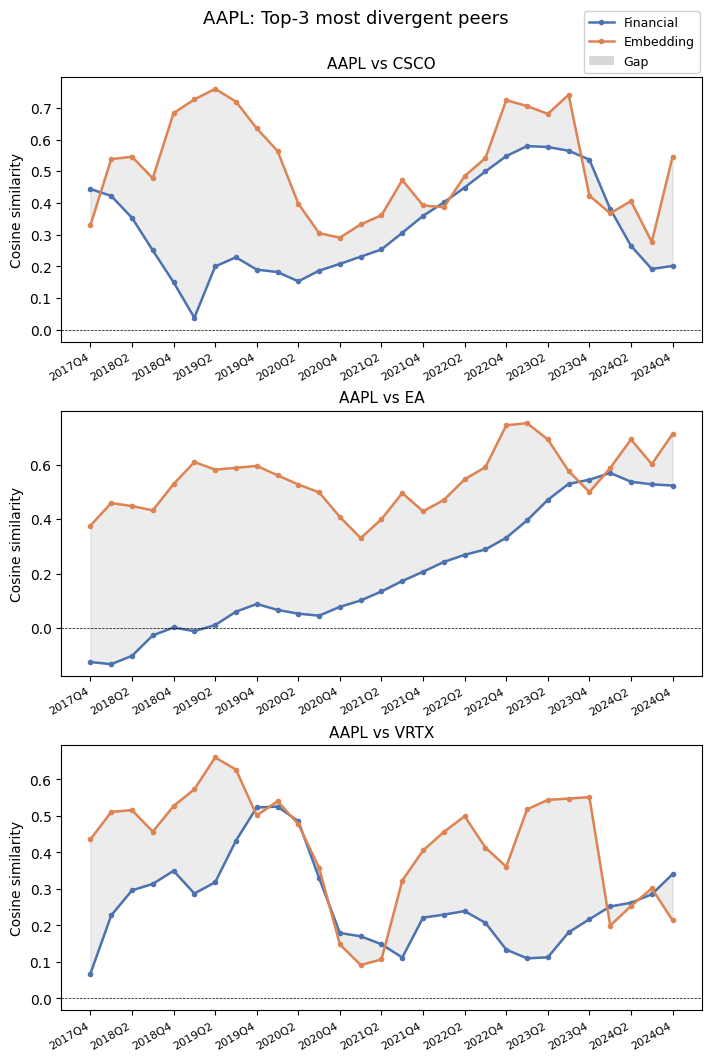

,peer,cos_fin,cos_emb,delta,score
0,CSCO,0.3152,0.7225,-0.4073,0.1284
1,EA,0.3128,0.7219,-0.4091,0.1280
2,VRTX,0.4173,0.7227,-0.3054,0.1274


In [111]:
# Change the ticker to any company present in company_list
TICKER = "AAPL"
result = plot_divergent_pairs(TICKER, n=3)
display(result)

In [74]:
# Inspect available tickers
print(f"Available companies ({len(company_list)}):")
company_list

Available companies (2263):


['A',
 'AAME',
 'AAP',
 'AAPL',
 'AASP',
 'AAT',
 'ABBV',
 'ABCB',
 'ABCP',
 'ABEO',
 'ABG',
 'ABM',
 'ABR',
 'ABR-PD',
 'ABT',
 'ACAD',
 'ACCO',
 'ACCS',
 'ACGL',
 'ACGLN',
 'ACGLO',
 'ACHC',
 'ACHV',
 'ACLS',
 'ACM',
 'ACN',
 'ACNB',
 'ACNT',
 'ACR',
 'ACR-PC',
 'ACR-PD',
 'ACRE',
 'ACRG',
 'ACTG',
 'ACU',
 'AD',
 'ADAM',
 'ADAMG',
 'ADAMI',
 'ADAMN',
 'ADAMZ',
 'ADBE',
 'ADC',
 'ADC-PA',
 'ADI',
 'ADM',
 'ADMA',
 'ADMT',
 'ADP',
 'ADSK',
 'ADTN',
 'ADUS',
 'AEE',
 'AEHR',
 'AEIS',
 'AEO',
 'AEP',
 'AERGP',
 'AES',
 'AFG',
 'AFGB',
 'AFGD',
 'AFL',
 'AGM',
 'AGM-PD',
 'AGM-PE',
 'AGM-PG',
 'AGM-PH',
 'AGNC',
 'AGNCM',
 'AGNCN',
 'AGNCO',
 'AGNCP',
 'AGNCZ',
 'AGO',
 'AGX',
 'AGYS',
 'AHNRF',
 'AHT',
 'AHT-PD',
 'AHT-PF',
 'AHT-PG',
 'AHT-PH',
 'AHT-PI',
 'AIFF',
 'AIG',
 'AIM',
 'AIMI',
 'AIN',
 'AIRT',
 'AIRTP',
 'AIT',
 'AIV',
 'AIZ',
 'AIZN',
 'AJG',
 'AKAM',
 'AKR',
 'ALB',
 'ALB-PA',
 'ALCO',
 'ALE',
 'ALEX',
 'ALG',
 'ALGN',
 'ALGT',
 'ALL-PH',
 'ALL-PI',
 'ALL-PJ',
 'ALLY',
 '

In [59]:
pairs = get_divergent_pairs(ticker, n=100)
pairs

,peer,cos_fin,cos_emb,delta
0,PFG,-0.7175,0.9458,-1.6633
1,MTB-PJ,-0.7024,0.9178,-1.6202
2,MTB,-0.7024,0.9178,-1.6202
3,MTB-PK,-0.7023,0.9173,-1.6196
4,MTB-PH,-0.7015,0.9178,-1.6193
...,...,...,...,...
95,LEN-B,-0.2434,0.8953,-1.1387
96,WBD,-0.2176,0.9183,-1.1359
97,LEN,-0.2434,0.8902,-1.1335
98,CHTR,-0.2132,0.9110,-1.1242
